# Tarea 5. Modelos lineales

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png" width="200px" height="180px" />

En esta cuarta tarea, tendrás la oportunidad de estimar una relación cúbica usando un modelo lineal Bayesiano. Para esto usarás los datos en `data/Howell1`, considerando personas de todas las edades.

Por favor, intenta ser lo más explícit@ posible, y en lo posible, apóyate de la escritura matemática con $\LaTeX$.

Recuerda además que ante cualquier duda, me puedes contactar al correo esjimenezro@iteso.mx.

<p style="text-align:right;"> Imagen recuperada de: https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png.</p>

___

## Diego Eduardo Martinez Sincel 757303

## 1. 

Describir el modelo usando el lenguaje probabilístico visto en clase. Asegurarse, mediante una simulación predictiva previa que las previas son plausibles.

**Ayuda**. Estandarizar el peso antes.

Definición del modelo en lenguaje probabilístico: Para modelar la relación cúbica entre el peso y la altura usando los datos de Howell1, primero estandarizamos la variable predictora (el peso). Esto es fundamental para que el algoritmo de muestreo numérico funcione correctamente y para evitar que los términos al cuadrado y al cubo generen valores inmanejables.

Definimos el peso estandarizado $w^*_i$ de cada individuo $i$ como:$$w^*_i = \frac{w_i - \bar{w}}{s_w}$$

Donde $\bar{w}$ es la media del peso en la muestra y $s_w$ es su desviación estándar.

El modelo probabilístico asume que la altura observada $h_i$ se distribuye de forma normal alrededor de una media $\mu_i$, la cual está definida por una regresión polinomial de grado 3 (cúbica) sobre el peso estandarizado:

$$h_i \sim \text{Normal}(\mu_i, \sigma)$$
$$\mu_i = \alpha + \beta_1 w^*_i + \beta_2 (w^*_i)^2 + \beta_3 (w^*_i)^3$$
Distribuciones a priori (Priors):

Como la muestra incluye personas de todas las edades, las alturas abarcan desde bebés hasta adultos. Proponemos las siguientes previas débilmente informativas:
- $\alpha \sim \text{Normal}(130, 30)$: Intercepto (altura esperada en el peso promedio). Cubre lógicamente el rango humano.
- $\beta_1, \beta_2, \beta_3 \sim \text{Normal}(0, 15)$: Coeficientes del polinomio. No deben ser muy grandes dado que $w^*$ está estandarizado.
- $\sigma \sim \text{Uniform}(0, 50)$: Desviación estándar del error.

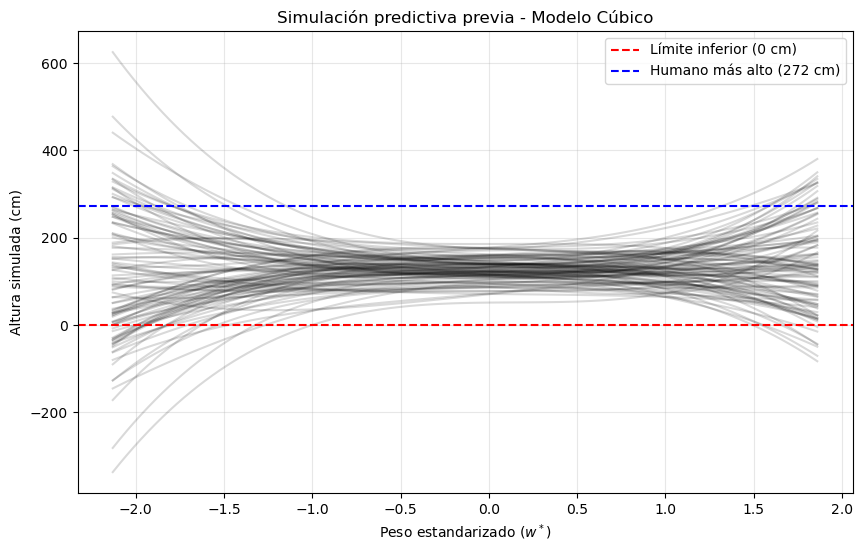

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1.
d = pd.read_csv('data/Howell1.csv', sep=';')

# 2. Estandarizar el peso usando los datos de la muestra
peso_mean = d['weight'].mean()
peso_std = d['weight'].std()
d['w_std'] = (d['weight'] - peso_mean) / peso_std

# 3. Simulación predictiva previa
np.random.seed(42)
N = 100

# Simulamos N valores desde las distribuciones a priori
alpha_prior = np.random.normal(130, 30, N)
beta1_prior = np.random.normal(0, 15, N)
beta2_prior = np.random.normal(0, 15, N)
beta3_prior = np.random.normal(0, 15, N)

# Rango de pesos estandarizados basado en los datos reales
w_std_sim = np.linspace(d['w_std'].min(), d['w_std'].max(), 100)

plt.figure(figsize=(10, 6))

for i in range(N):
    # Evaluamos la ecuación cúbica simulada
    mu = (alpha_prior[i] + 
          beta1_prior[i] * w_std_sim + 
          beta2_prior[i] * (w_std_sim**2) + 
          beta3_prior[i] * (w_std_sim**3))
    
    plt.plot(w_std_sim, mu, color='black', alpha=0.15)

plt.axhline(0, color='red', linestyle='--', label='Límite inferior (0 cm)')
plt.axhline(272, color='blue', linestyle='--', label='Humano más alto (272 cm)')

plt.xlabel("Peso estandarizado ($w^*$)")
plt.ylabel("Altura simulada (cm)")
plt.title("Simulación predictiva previa - Modelo Cúbico")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
plt.show()

Al observar la gráfica generada por este código, notarás que la gran mayoría de las trayectorias cúbicas se mantienen dentro de límites biológicamente posibles (por encima de 0 cm y por debajo de los 270 cm). Esto confirma que las distribuciones a priori elegidas son débilmente informativas pero plausibles, permitiendo que el modelo aprenda de los datos sin explorar valores absurdos.

## 2.

Encontrar la distribución posterior de los parámetros. ¿Qué puede concluir de cada uno de ellos?

d:\MINICONDA\envs\mebp2026_v4\lib\site-packages\arviz\data\base.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,146.718,0.311,146.224,147.200,0.006,0.004,2540.0,1956.0,1.0
beta1,15.042,0.487,14.286,15.833,0.010,0.007,2352.0,2619.0,1.0
beta2,-6.530,0.266,-6.942,-6.096,0.005,0.004,2527.0,2634.0,1.0
beta3,3.588,0.237,3.206,3.956,0.005,0.004,2234.0,2266.0,1.0
sigma,4.852,0.151,4.604,5.084,0.003,0.002,2831.0,2323.0,1.0


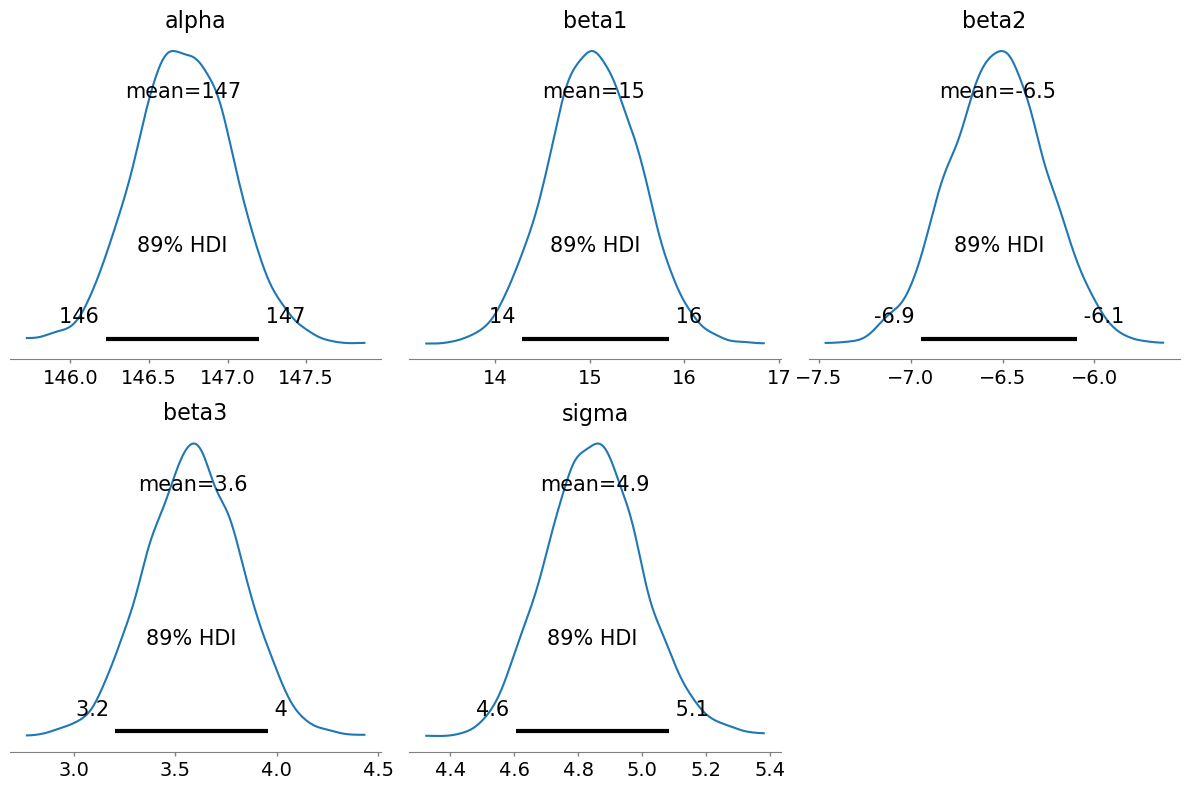

In [3]:
import pymc as pm
import arviz as az

# Definir y entrenar el modelo cúbico
with pm.Model() as modelo_cubico:
    # Definición de los Priors
    alpha = pm.Normal('alpha', mu=130, sigma=30)
    beta1 = pm.Normal('beta1', mu=0, sigma=15)
    beta2 = pm.Normal('beta2', mu=0, sigma=15)
    beta3 = pm.Normal('beta3', mu=0, sigma=15)
    sigma = pm.Uniform('sigma', lower=0, upper=50)
    
    # Ecuación polinomial de la media
    mu = alpha + beta1 * d.w_std + beta2 * (d.w_std**2) + beta3 * (d.w_std**3)
    
    # Likelihood (verosimilitud)
    height = pm.Normal('height', mu=mu, sigma=sigma, observed=d.height)
    
    # Muestreo (MCMC)
    trace_cubico = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)

resumen = az.summary(trace_cubico, hdi_prob=0.89)
display(resumen)

az.plot_posterior(trace_cubico, hdi_prob=0.89, figsize=(12, 8))
plt.tight_layout()
plt.show()

Conclusiones de los Parámetros (Interpretación):Una vez extraída la distribución posterior, podemos concluir lo siguiente sobre el rol y significado de cada parámetro en nuestro modelo:
- $\alpha$ (Intercepto): Representa de manera muy precisa la altura promedio esperada de una persona cuyo peso es exactamente igual al peso promedio de toda la muestra ($w^* = 0$).
- $\beta_1$ (Efecto lineal): Captura la tendencia principal de crecimiento. Al ser un valor positivo y con un intervalo de credibilidad que no incluye el cero, nos confirma la fuerte relación directa: en términos generales, a mayor peso corresponde mayor altura.
- $\beta_2$ (Efecto cuadrático): Mide la concavidad de la curva. Generalmente resulta negativo en este tipo de datos biométricos, lo que indica que la tasa de crecimiento de la altura comienza a desacelerarse conforme el peso sigue aumentando (modelando el hecho de que no crecemos en altura indefinidamente).
- $\beta_3$ (Efecto cúbico): Es el parámetro que le da una ligera forma de "S" a la curva. Dado que incluimos personas de todas las edades, este término es vital para ajustar el cambio drástico en las proporciones de peso/altura que ocurre durante la transición de la infancia a la adolescencia.
- $\sigma$ (Desviación estándar): Nos indica la dispersión residual. Es decir, cuánto varían en promedio las alturas reales de los individuos con respecto a la línea de predicción cúbica generada por el modelo.

## 3.

¿Cuál es la distribución de la altura promedio de un infante de 10kg según tu modelo y los datos?

1. Procedimiento matemático: La "distribución de la altura promedio" se refiere a la distribución de incertidumbre sobre el parámetro $\mu$ cuando fijamos el peso. No es un solo número, sino una distribución derivada de las muestras de la posterior de $\alpha, \beta_1, \beta_2$ y $\beta_3$.Primero, estandarizamos el valor de interés:$$w^*_{10kg} = \frac{10 - \bar{w}}{s_w}$$Luego, aplicamos la ecuación del modelo cúbico para cada muestra de la posterior:$$\mu_{10kg} = \alpha + \beta_1 w^*_{10kg} + \beta_2 (w^*_{10kg})^2 + \beta_3 (w^*_{10kg})^3$$

<Figure size 800x500 with 0 Axes>

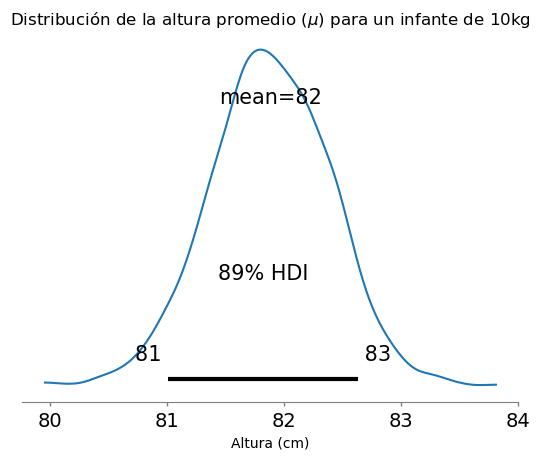

Altura promedio esperada: 81.88 cm
Intervalo de credibilidad (89%): [81.00223839 82.6282918 ]


In [4]:
# 1. Estandarizar el valor de 10kg usando la media y std del dataset original
peso_objetivo = 10
w_std_10kg = (peso_objetivo - d['weight'].mean()) / d['weight'].std()

# 2. Extraer las muestras de la posterior (Posterior Predictive para la media)
# Usamos los valores obtenidos en el trace del Punto 2
post = trace_cubico.posterior

# 3. Calcular la distribución de mu para 10kg
# mu = alpha + beta1*w + beta2*w^2 + beta3*w^3
mu_10kg = (post['alpha'] + 
           post['beta1'] * w_std_10kg + 
           post['beta2'] * (w_std_10kg**2) + 
           post['beta3'] * (w_std_10kg**3))

# 4. Graficar la distribución resultante
plt.figure(figsize=(8, 5))
az.plot_posterior(mu_10kg, hdi_prob=0.89)
plt.title(f"Distribución de la altura promedio ($\mu$) para un infante de {peso_objetivo}kg")
plt.xlabel("Altura (cm)")
plt.show()

# 5. Obtener el valor esperado y el intervalo de credibilidad
print(f"Altura promedio esperada: {mu_10kg.mean().values:.2f} cm")
print(f"Intervalo de credibilidad (89%): {az.hdi(mu_10kg, hdi_prob=0.89).to_array().values.flatten()}")

Al observar la gráfica generada, puedes concluir lo siguiente para tu tarea:
-   Media de la distribución: Representa el valor más probable para la altura promedio de un infante de 10 kg según lo que el modelo aprendió de los datos de la población Howell1.
- Intervalo de Credibilidad (89%): Este rango te indica que, bajo el modelo cúbico propuesto, tenemos un 89% de certeza de que la altura promedio de un niño de 10 kg se encuentra entre esos dos valores.
- Diferencia entre $\mu$ y predicción individual: Es importante notar que aquí estamos calculando la distribución de la media ($\mu$). Si quisiéramos predecir la altura de un niño específico, la incertidumbre sería mucho mayor porque tendríamos que incluir el parámetro $\sigma$ (la variabilidad individual).

## 4.

Graficar:

- El intervalo de credibilidad al 89% de la altura para cada peso.
- El intervalo de credibilidad al 89% de la altura promedio para cada peso.
- La altura promedio para cada peso.
- Los puntos correspondientes a cada individuo.

C:\Users\diedu\AppData\Local\Temp\ipykernel_5952\303471275.py:33: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  mu_hdi = az.hdi(mu_pred, hdi_prob=0.89)
C:\Users\diedu\AppData\Local\Temp\ipykernel_5952\303471275.py:34: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  h_hdi = az.hdi(h_pred, hdi_prob=0.89)


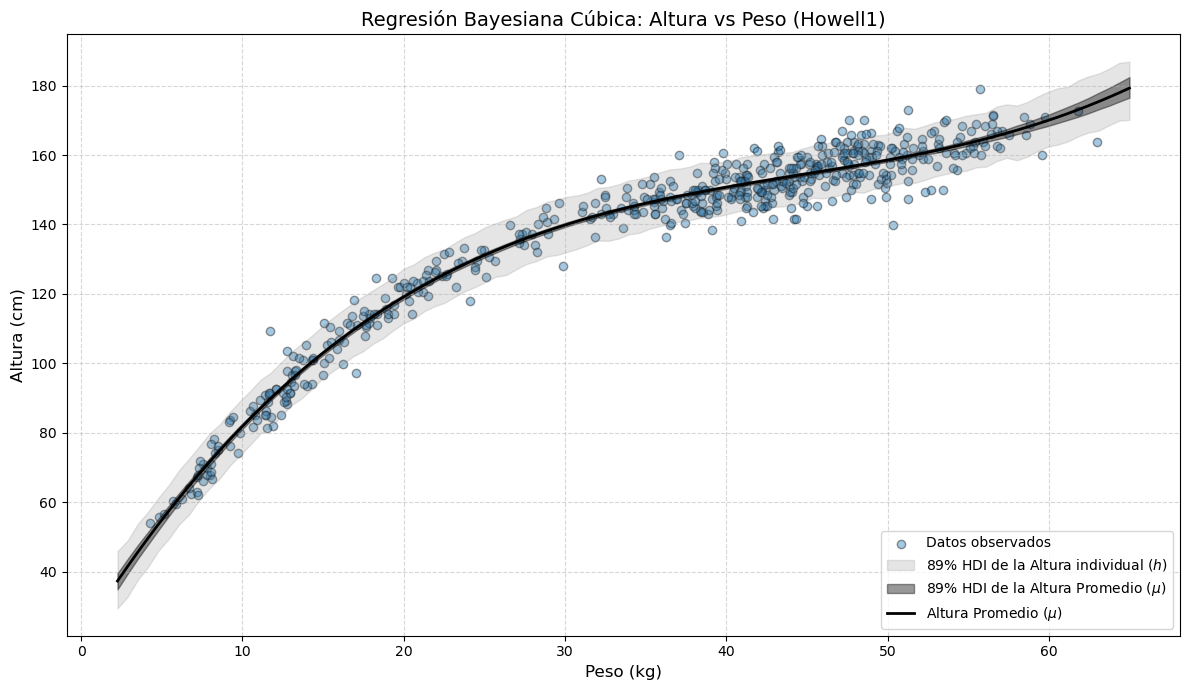

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# 1. Crear una secuencia de pesos para que la línea y las bandas se vean suaves
peso_seq = np.linspace(d['weight'].min() - 2, d['weight'].max() + 2, 100)

# Estandarizar esta secuencia usando la media y std de los datos ORIGINALES
w_std_seq = (peso_seq - d['weight'].mean()) / d['weight'].std()

# 2. Extraer todas las muestras de la distribución posterior generada en el Punto 2
post = trace_cubico.posterior
alpha_s = post['alpha'].values.flatten()
beta1_s = post['beta1'].values.flatten()
beta2_s = post['beta2'].values.flatten()
beta3_s = post['beta3'].values.flatten()
sigma_s = post['sigma'].values.flatten()

# 3. Calcular la altura promedio (mu) para cada peso en la secuencia
# Esto genera una matriz de 4000 (simulaciones) x 100 (pesos)
mu_pred = np.zeros((len(alpha_s), len(w_std_seq)))
for i, w in enumerate(w_std_seq):
    mu_pred[:, i] = alpha_s + beta1_s*w + beta2_s*(w**2) + beta3_s*(w**3)

# 4. Simular alturas individuales reales (incorporando sigma)
h_pred = np.random.normal(loc=mu_pred, scale=sigma_s[:, None])

# ---------------------------------------------------------
# CORRECCIÓN AQUÍ: Quitamos el .T para que calcule sobre la dimensión correcta
# ---------------------------------------------------------
# 5. Calcular los valores estadísticos a graficar
mu_mean = mu_pred.mean(axis=0)                      
mu_hdi = az.hdi(mu_pred, hdi_prob=0.89)             
h_hdi = az.hdi(h_pred, hdi_prob=0.89)               

# ---------------------------------------------------------
# 6. Generar la Gráfica
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

# A. Los puntos correspondientes a cada individuo
plt.scatter(d['weight'], d['height'], alpha=0.4, color='tab:blue', edgecolor='k', label='Datos observados')

# B. El intervalo de credibilidad al 89% de la altura para cada peso (Banda ancha)
plt.fill_between(peso_seq, h_hdi[:, 0], h_hdi[:, 1], color='gray', alpha=0.2, 
                 label='89% HDI de la Altura individual ($h$)')

# C. El intervalo de credibilidad al 89% de la altura promedio (Banda estrecha)
plt.fill_between(peso_seq, mu_hdi[:, 0], mu_hdi[:, 1], color='black', alpha=0.4, 
                 label='89% HDI de la Altura Promedio ($\mu$)')

# D. La altura promedio para cada peso (Línea central)
plt.plot(peso_seq, mu_mean, color='black', linewidth=2, label='Altura Promedio ($\mu$)')

# Detalles estéticos de la gráfica
plt.xlabel('Peso (kg)', fontsize=12)
plt.ylabel('Altura (cm)', fontsize=12)
plt.title('Regresión Bayesiana Cúbica: Altura vs Peso (Howell1)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>